In [4]:
# from google.colab import drive
# from pathlib import Path
# drive.mount("/content/drive")

If you haven't already:

1. Open the shared folder link in Google Drive:  
   https://drive.google.com/drive/folders/1fm2lM_DcFoASB4RRQIesk9e5mJlLoIl9?usp=sharing
2. Right-click the folder **`celeba`** → **Add shortcut to Drive**
3. Put the shortcut somewhere inside **My Drive**
4. **Copy the path** to the folder that contains `celeba`

Then, in the notebook, **set the root path manually** so that it points to the **parent directory of `celeba`**:

```python
# Example (change this to YOUR actual path in My Drive)
CELEBA_ROOT = Path("/content/drive/MyDrive/datasets")

# This must exist:
# /content/drive/MyDrive/datasets/celeba/

In [ ]:
CELEBA_ROOT = Path("/content/drive/MyDrive")

In [ ]:
from torchvision.datasets import CelebA
from torchvision import transforms

transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = CelebA(
    root=str(CELEBA_ROOT),
    split="train",
    target_type="attr",
    transform=transform,
    download=False  # <--- we already have the files in Drive
)

val_dataset = CelebA(root=str(CELEBA_ROOT), split="valid", target_type="attr", transform=transform, download=False)
test_dataset = CelebA(root=str(CELEBA_ROOT), split="test",  target_type="attr", transform=transform, download=False)

print("Train size:", len(dataset))
print("Valid size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 162770
Valid size: 19867
Test size: 19962


In [ ]:
img, attrs = dataset[0]
print("Image tensor shape:", img.shape)  # [3, 128, 128]
print("Attrs shape:", attrs.shape)       # [40]
print("Attrs (first 10):", attrs[:10])

Image tensor shape: torch.Size([3, 64, 64])
Attrs shape: torch.Size([40])
Attrs (first 10): tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0])


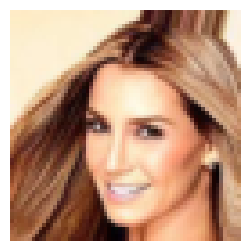

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()
